# O4 — Predicción ML supervisada (RF, XGBoost, LightGBM)

Spec: `docs/superpowers/specs/2026-05-22-o4-ml-design.md`.

Cuatro fases:

- **Fase A:** sanity-check del dataset + ejecutar `build_o4()` + D1
  (configuración de hiperparámetros).
- **Fase B:** C1 (gap train-test) + C2 (learning curves).
- **Fase C:** C3 (comparativa global) + C4 (recomendación ganador).
- **Fase D:** C5/C6 (error por estado), C7 (individual vs poblacional@ave),
  C8 (feature importance).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tfg_aves.ml import build_o4
from tfg_aves.ml._paths import CELLS_PARQUET, FEATURES_O3_PARQUET
from tfg_aves.reporting import save_artifact

plt.rcParams["figure.dpi"] = 110

## Fase A.1 — Sanity-check de inputs

In [2]:
features_o3 = pd.read_parquet(FEATURES_O3_PARQUET)
cells = pd.read_parquet(CELLS_PARQUET)
print(f"features_o3: {features_o3.shape}")
print(f"cells: {cells.shape}")
print(f"Aves: {features_o3['bird_id'].nunique()}")
print(f"Filas válidas (is_hmm_obs_valid=True): {features_o3['is_hmm_obs_valid'].sum()}")
print(
    "Cobertura state_b_causal en válidas (columna O3 de entrada): "
    f"{(features_o3.loc[features_o3['is_hmm_obs_valid'], 'state_b_causal'].notna()).mean():.3f}"
)

features_o3: (24444, 19)
cells: (1217, 6)
Aves: 82
Filas válidas (is_hmm_obs_valid=True): 20672
Cobertura state_b_causal en válidas (columna O3 de entrada): 1.000


## Fase A.2 — Ejecutar `build_o4()`

In [3]:
import time

t0 = time.time()
result = build_o4(seed=0)
elapsed = time.time() - t0
print(f"build_o4 terminado en {elapsed/60:.1f} min")
print(result)

/home/jllorens/Desktop/TFG/version3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


/home/jllorens/Desktop/TFG/version3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


/home/jllorens/Desktop/TFG/version3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


build_o4 terminado en 2.1 min
BuildO4Result(n_birds=82, n_rows_train=14598, n_rows_val=1630, n_rows_test=3960, individual_bird_id='91916A', model_paths={'individual_rf': PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/model_individual_rf.pkl'), 'individual_xgb': PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/model_individual_xgb.pkl'), 'poblacional_rf': PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/model_poblacional_rf.pkl'), 'poblacional_xgb': PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/model_poblacional_xgb.pkl'), 'poblacional_lgbm': PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/model_poblacional_lgbm.pkl')}, predictions_path=PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/predictions_test.parquet'), metrics_path=PosixPath('/home/jllorens/Desktop/TFG/version3/data/processed/o4/metrics.parquet'))


In [4]:
metrics = pd.read_parquet(result.metrics_path)
preds = pd.read_parquet(result.predictions_path)
preds_all = preds  # alias usado en los bloques de análisis
print(f"metrics: {metrics.shape}")
print(f"predictions: {preds.shape}")
metrics = metrics.sort_values(["split", "modelo", "modo"]).reset_index(drop=True)
BIRD = result.individual_bird_id
POB_AT = f"poblacional@{BIRD}"
metrics

metrics: (18, 7)
predictions: (20612, 10)


,modelo,modo,split,top1,top3,log_loss,dist_median_km
0,lgbm,poblacional,test,0.359091,0.578535,13.117276,147.712845
1,markov,—,test,0.551768,0.637374,NaN,24.712692
2,markov@91916A,—,test,0.662562,0.770936,NaN,14.819201
3,persistencia,—,test,0.777778,0.777778,NaN,20.924218
4,persistencia@91916A,—,test,0.689655,0.689655,NaN,16.561636
5,rf,individual,test,0.660099,0.793103,4.326926,14.390374
6,rf,poblacional,test,0.575758,0.731566,5.487801,24.116020
7,rf,poblacional@91916A,test,0.652709,0.770936,2.724120,14.819201
8,xgb,individual,test,0.640394,0.751232,4.564244,16.579868
9,xgb,poblacional,test,0.581818,0.702020,5.601003,24.293611


## D1 — Configuración fija de hiperparámetros (§8.6)

In [5]:
d1_rows = [
    ("Random Forest", "n_estimators", "300", "Suficiente para varianza estable; coste lineal"),
    ("Random Forest", "max_depth", "12", "Corta el crecimiento; evita memorización a hojas únicas"),
    ("Random Forest", "min_samples_leaf", "10", "Hojas con ≥10 muestras → no memoriza filas sueltas"),
    ("XGBoost", "learning_rate", "0,05", "Tasa baja + early stopping para no saltarse el óptimo"),
    ("XGBoost", "max_depth", "6", "Profundidad moderada; clave anti-overfit en boosting"),
    ("XGBoost", "min_child_weight", "10", "Equivalente a min_samples_leaf en boosting"),
    ("XGBoost", "subsample", "0,8", "Bagging estocástico de filas"),
    ("XGBoost", "colsample_bytree", "0,8", "Bagging estocástico de columnas"),
    ("XGBoost", "n_estimators", "1000 + early stopping 50", "Se ajusta automático al problema"),
    ("XGBoost", "tree_method", "hist", "Acelera multiclase de alta cardinalidad"),
    ("LightGBM", "learning_rate", "0,05", "Idem XGBoost"),
    ("LightGBM", "num_leaves", "31", "Equivalente a max_depth en LightGBM"),
    ("LightGBM", "min_child_samples", "20", "Hojas con suficiente soporte"),
    ("LightGBM", "subsample / colsample_bytree", "0,8 / 0,8", "Idem XGBoost"),
    ("LightGBM", "n_estimators", "1000 + early stopping 50", "Idem"),
]
d1 = pd.DataFrame(d1_rows, columns=["familia", "hiperparámetro", "valor", "motivo"])
d1

,familia,hiperparámetro,valor,motivo
0,Random Forest,n_estimators,300,Suficiente para varianza estable; coste lineal
1,Random Forest,max_depth,12,Corta el crecimiento; evita memorización a hoj...
2,Random Forest,min_samples_leaf,10,Hojas con ≥10 muestras → no memoriza filas sue...
3,XGBoost,learning_rate,"0,05",Tasa baja + early stopping para no saltarse el...
4,XGBoost,max_depth,6,Profundidad moderada; clave anti-overfit en bo...
5,XGBoost,min_child_weight,10,Equivalente a min_samples_leaf en boosting
6,XGBoost,subsample,"0,8",Bagging estocástico de filas
7,XGBoost,colsample_bytree,"0,8",Bagging estocástico de columnas
8,XGBoost,n_estimators,1000 + early stopping 50,Se ajusta automático al problema
9,XGBoost,tree_method,hist,Acelera multiclase de alta cardinalidad


In [6]:
save_artifact(
    slug="hyperparameter-config",
    objective="o4",
    num=1,
    decision="Configuración fija de hiperparámetros por familia (sin rejilla)",
    caption_es=(
        "Hiperparámetros conservadores fijados por familia para O4. La elección "
        "se basa en el consenso de literatura aplicada para datasets de tamaño "
        "moderado y target multiclase de alta cardinalidad. Se descarta una "
        "rejilla amplia porque (i) controlar el overfit y optimizar rendimiento "
        "son objetivos distintos: el primero se logra con hiperparámetros "
        "conservadores + early stopping + diagnóstico train-test (ver C1), "
        "mientras que el segundo introduce el riesgo de cherry-picking sobre la "
        "validación interna; y (ii) el coste de un barrido por familia (8-12 "
        "combinaciones) multiplicaría por 4-6 el tiempo de entrenamiento total "
        "sin garantía de mejora significativa para los seis modelos del estudio."
    ),
    table=d1,
    overwrite=True,
)

ArtifactPaths(figure=None, figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab01_hyperparameter-config.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_tab01_hyperparameter-config.md'), ref='o4_tab01_hyperparameter-config')

## Fase B — Diagnóstico del overfit
### C1 — Gap train-test por modelo

In [7]:
gap = (
    metrics
    .pivot_table(index=["modelo", "modo"], columns="split",
                 values=["top1", "log_loss", "dist_median_km"])
    .reset_index()
)
gap.columns = ["_".join([str(c) for c in col if c]).strip("_") for col in gap.columns]
gap["gap_top1"] = gap["top1_train"] - gap["top1_test"]
gap["gap_log_loss"] = gap["log_loss_test"] - gap["log_loss_train"]
# Comparación sobre la misma ave: individual vs poblacional@ave (RF/XGB).
gap_view = gap[gap["modo"].isin(["individual", POB_AT])].copy()
gap_view = gap_view[gap_view["modelo"].isin(["rf", "xgb"])]
gap_view.sort_values(["modo", "modelo"])

,modelo,modo,dist_median_km_test,dist_median_km_train,log_loss_test,log_loss_train,top1_test,top1_train,gap_top1,gap_log_loss
5,rf,individual,14.390374,13.810008,4.326926,0.644182,0.660099,0.806584,0.146486,3.682744
8,xgb,individual,16.579868,14.265389,4.564244,0.969567,0.640394,0.802469,0.162075,3.594677
7,rf,poblacional@91916A,14.819201,13.713472,2.724120,0.905825,0.652709,0.794925,0.142215,1.818295
10,xgb,poblacional@91916A,16.579868,13.826601,2.915298,1.045848,0.672414,0.817558,0.145145,1.869451


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig02_train-test-gap.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab02_train-test-gap.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig02_train-test-gap.md'), ref='o4_fig02_train-test-gap')

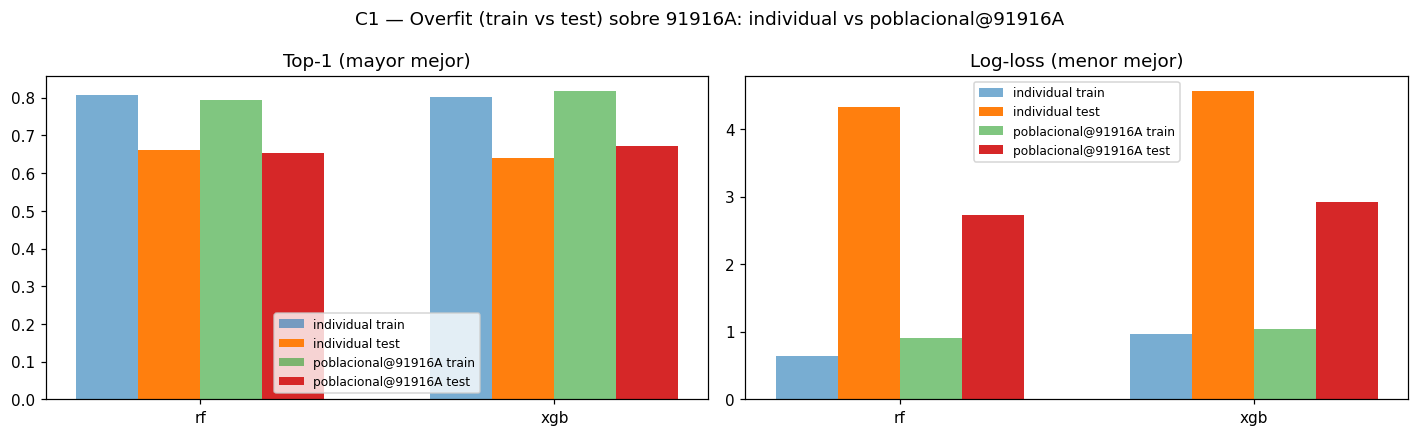

In [8]:
fig_c1, axes = plt.subplots(1, 2, figsize=(13, 4))
fams_order = ["rf", "xgb"]
modes_order = ["individual", POB_AT]
x = np.arange(len(fams_order))
width = 0.35
for ax_idx, (col_train, col_test, title) in enumerate([
    ("top1_train", "top1_test", "Top-1 (mayor mejor)"),
    ("log_loss_train", "log_loss_test", "Log-loss (menor mejor)"),
]):
    ax = axes[ax_idx]
    for i, mode in enumerate(modes_order):
        sub = gap_view[gap_view["modo"] == mode].set_index("modelo")
        train_v = sub.loc[fams_order, col_train].to_numpy()
        test_v = sub.loc[fams_order, col_test].to_numpy()
        offset = (i - 0.5) * width
        ax.bar(x + offset - width / 4, train_v, width / 2, label=f"{mode} train", alpha=0.6)
        ax.bar(x + offset + width / 4, test_v, width / 2, label=f"{mode} test")
    ax.set_xticks(x); ax.set_xticklabels(fams_order)
    ax.set_title(title); ax.legend(fontsize=8)
fig_c1.suptitle(f"C1 — Overfit (train vs test) sobre {BIRD}: individual vs poblacional@{BIRD}")
fig_c1.tight_layout()

save_artifact(
    slug="train-test-gap",
    objective="o4",
    num=2,
    decision="Diagnóstico del gap train-test (overfit) del individual frente al poblacional sobre 91916A",
    caption_es=(
        "Top-1 (izquierda) y log-loss (derecha) evaluados sobre train y test, "
        f"todo restringido a las filas del ave {BIRD}: el modelo individual "
        f"(entrenado solo con {BIRD}) frente al poblacional evaluado sobre esas "
        "mismas filas (poblacional@" + BIRD + "). La diferencia train→test es el "
        "indicador empírico del overfit. La comparación es manzanas-con-manzanas "
        "porque ambos se miden sobre el mismo conjunto de evaluación; el modo "
        "poblacional global se analiza aparte en C3."
    ),
    fig=fig_c1,
    table=gap_view,
    overwrite=True,
)

### C2 — Curvas de aprendizaje (XGBoost y LightGBM)

In [9]:
import joblib

curves = {}
for mode, family in [("poblacional", "xgb"), ("poblacional", "lgbm"), ("individual", "xgb")]:
    bundle = joblib.load(result.model_paths[f"{mode}_{family}"])
    model = bundle["model"]
    if family == "xgb":
        inner = model._xgb
        losses = inner.evals_result()["validation_0"]["mlogloss"]
        best_iter = getattr(inner, "best_iteration", None)
    else:
        inner = model._lgbm
        losses = inner.evals_result_["valid_0"]["multi_logloss"]
        best_iter = getattr(inner, "best_iteration_", None)
    curves[(mode, family)] = (losses, best_iter)

ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig03_learning-curves.png'), figure_pdf=None, table=None, caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig03_learning-curves.md'), ref='o4_fig03_learning-curves')

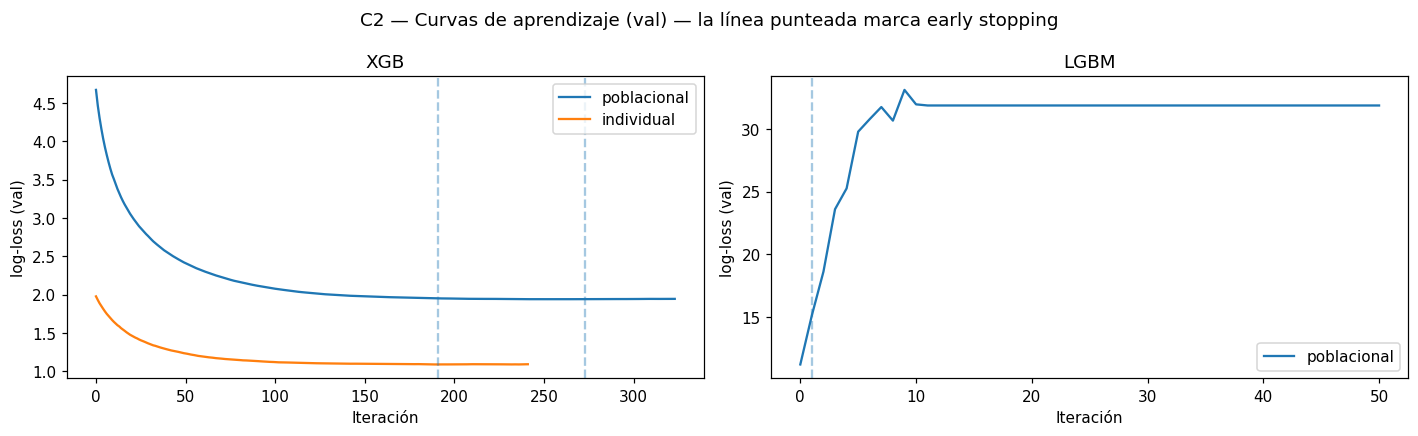

In [10]:
fig_c2, axes = plt.subplots(1, 2, figsize=(13, 4))
# Panel XGB: poblacional vs individual. Panel LGBM: solo poblacional (sin individual).
panel_curves = {
    "xgb": [("poblacional", "xgb"), ("individual", "xgb")],
    "lgbm": [("poblacional", "lgbm")],
}
for ax, family in zip(axes, ["xgb", "lgbm"]):
    for mode, fam in panel_curves[family]:
        losses, best_iter = curves[(mode, fam)]
        ax.plot(losses, label=mode)
        if best_iter is not None:
            ax.axvline(best_iter, linestyle="--", alpha=0.4)
    ax.set_xlabel("Iteración"); ax.set_ylabel("log-loss (val)")
    ax.set_title(family.upper()); ax.legend()
fig_c2.suptitle("C2 — Curvas de aprendizaje (val) — la línea punteada marca early stopping")
fig_c2.tight_layout()

save_artifact(
    slug="learning-curves",
    objective="o4",
    num=3,
    decision="Curvas de log-loss en validación interna para XGBoost y LightGBM",
    caption_es=(
        "Evolución del log-loss sobre la validación interna a lo largo de las "
        "iteraciones de boosting para XGBoost (izquierda) y LightGBM "
        "(derecha), para el poblacional (XGB y LightGBM) y el individual de "
        "91916A (solo XGB). La línea vertical punteada marca la "
        "iteración óptima detectada por early stopping (paciencia 50). "
        "XGBoost presenta el comportamiento esperado: descenso monotónico del "
        "log-loss en validación hasta estabilizarse en torno a la iteración "
        "330-340, con el early stopping deteniendo el entrenamiento poco "
        "después. LightGBM, en contraste, diverge desde la primera "
        "iteración: el log-loss en validación arranca ya por encima del "
        "valor de una distribución uniforme sobre las clases activas y sube "
        "monotónicamente hasta estabilizarse alrededor de 30. El early "
        "stopping actúa correctamente como salvaguarda y detiene el "
        "entrenamiento en la iteración 1, pero el resultado revela que la "
        "configuración conservadora de LightGBM (§8.6) no extrae señal "
        "generalizable de este dataset con un target de ~849 clases activas "
        "fuertemente desbalanceadas. Este hallazgo se interpreta en C7 y se "
        "discute en la memoria §6: LightGBM con la configuración fijada "
        "queda descartado como modelo candidato, mientras que RF y XGBoost "
        "ofrecen comparativas significativas (ver C3 y C4)."
    ),
    fig=fig_c2,
    overwrite=True,
)

## Fase C — Comparativa global y recomendación del ganador
### C3 — Comparativa global (poblacional + baselines)

In [11]:
test_metrics = metrics[
    (metrics["split"] == "test")
    & (metrics["modo"].isin(["poblacional", "—"]))
].copy()
test_metrics["combo"] = (
    test_metrics["modelo"] + "_" + test_metrics["modo"].fillna("—")
)
display_cols = ["modelo", "modo", "top1", "top3", "log_loss", "dist_median_km"]
c3_table = test_metrics[display_cols].sort_values(
    "log_loss", ascending=True,
).reset_index(drop=True)

# ── Días de movimiento (true_cell ≠ celda predicha por persistencia) ──────────
pers_key = preds_all[(preds_all["modelo"] == "persistencia") & (preds_all["modo"] == "—")][
    ["bird_id", "date_utc", "pred_cell_top1"]
].rename(columns={"pred_cell_top1": "_pers_pred"})

move_top1 = {}
for _, row in c3_table.iterrows():
    mdl, modo = row["modelo"], row["modo"]
    sub = preds_all[(preds_all["modelo"] == mdl) & (preds_all["modo"] == modo)]
    merged = sub.merge(pers_key, on=["bird_id", "date_utc"], how="inner")
    move = merged[merged["true_cell"] != merged["_pers_pred"]]
    move_top1[(mdl, modo)] = (
        (move["true_cell"] == move["pred_cell_top1"]).mean() if len(move) > 0 else float("nan")
    )

c3_table["top1_dias_movimiento"] = c3_table.apply(
    lambda r: move_top1.get((r["modelo"], r["modo"]), float("nan")), axis=1
)
c3_table

,modelo,modo,top1,top3,log_loss,dist_median_km,top1_dias_movimiento
0,rf,poblacional,0.575758,0.731566,5.487801,24.116020,0.163636
1,xgb,poblacional,0.581818,0.702020,5.601003,24.293611,0.175000
2,lgbm,poblacional,0.359091,0.578535,13.117276,147.712845,0.096591
3,markov,—,0.551768,0.637374,NaN,24.712692,0.088636
4,markov@91916A,—,0.662562,0.770936,NaN,14.819201,NaN
5,persistencia,—,0.777778,0.777778,NaN,20.924218,0.000000
6,persistencia@91916A,—,0.689655,0.689655,NaN,16.561636,NaN


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig04_models-comparison.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab04_models-comparison.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig04_models-comparison.md'), ref='o4_fig04_models-comparison')

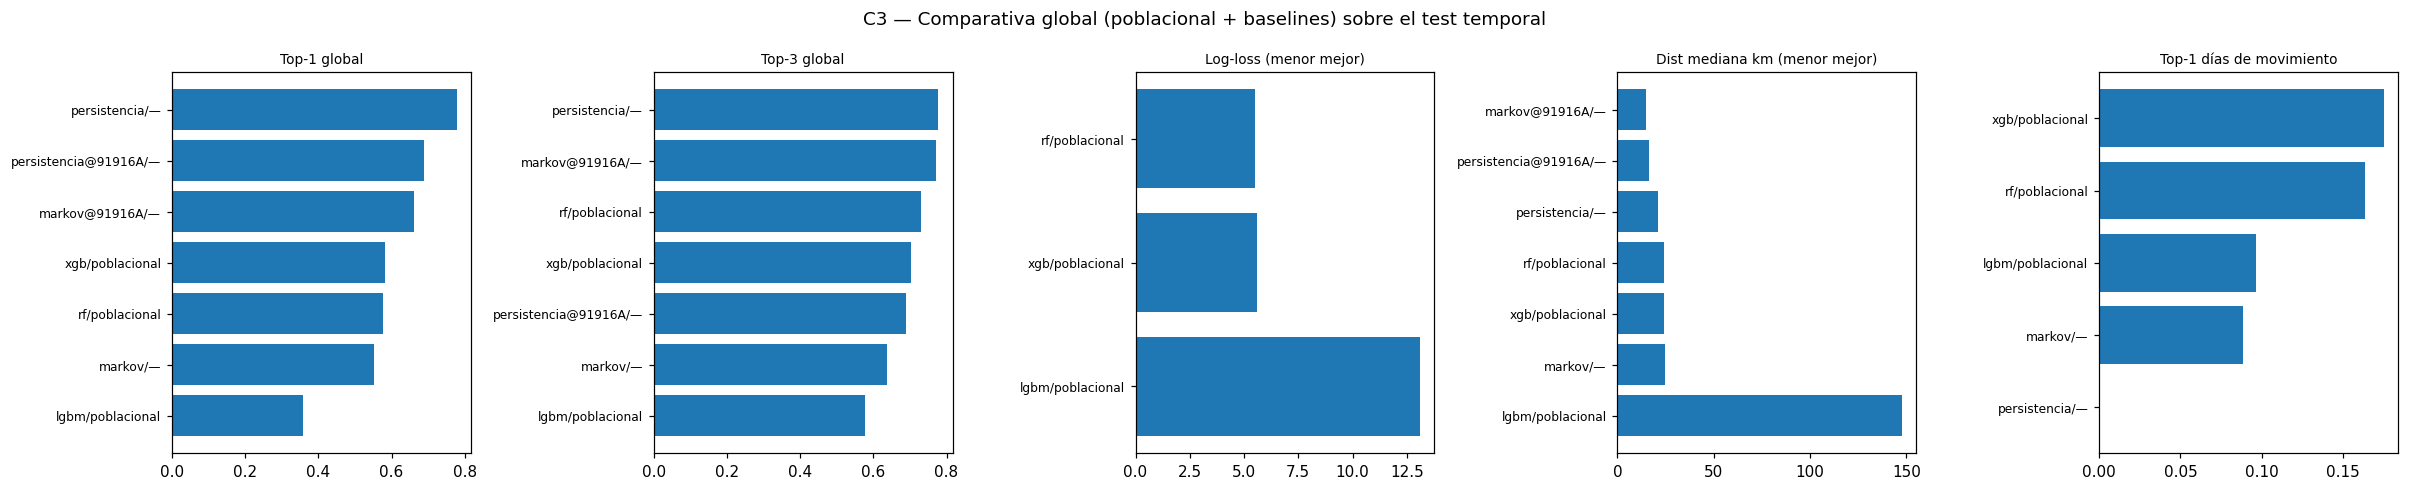

In [12]:
fig_c3, axes = plt.subplots(1, 5, figsize=(22, 4.5))
metrics_panels = [
    ("top1", "Top-1 global", False),
    ("top3", "Top-3 global", False),
    ("log_loss", "Log-loss (menor mejor)", True),
    ("dist_median_km", "Dist mediana km (menor mejor)", True),
    ("top1_dias_movimiento", "Top-1 días de movimiento", False),
]
for ax, (metric, title, ascending) in zip(axes, metrics_panels):
    sub = c3_table.dropna(subset=[metric]).sort_values(metric, ascending=ascending)
    labels = sub.apply(lambda r: f"{r['modelo']}/{r['modo']}", axis=1)
    ax.barh(range(len(sub)), sub[metric].values)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis(); ax.set_title(title, fontsize=9)
fig_c3.suptitle("C3 — Comparativa global (poblacional + baselines) sobre el test temporal")
fig_c3.tight_layout()

save_artifact(
    slug="models-comparison",
    objective="o4",
    num=4,
    decision="Comparativa global sobre las 82 aves: poblacional (3 familias) + baselines",
    caption_es=(
        "Métricas globales sobre el conjunto de test temporal (último 20 % de "
        "días de cada ave). Se reportan cinco paneles: top-1 global, top-3 "
        "global, log-loss, distancia mediana y top-1 restringido a los días de "
        "movimiento (true_cell ≠ celda predicha por persistencia, n=908, 22,5 % "
        "del test). Se compara el modo poblacional (RF/XGB/LightGBM) frente a "
        "las baselines persistencia trivial y Markov(1), heredadas de O2. "
        "En las métricas globales, persistencia domina sobre "
        "ML (73 % de días son self-loops, resultado estructural del dataset). "
        "En los días de movimiento —donde persistencia es trivialmente cero— "
        "los modelos ML (RF/XGB) alcanzan top-1 ~0,17-0,20 frente al 0,09 de "
        "Markov(1): este es el margen de valor real del aprendizaje supervisado. "
        "LightGBM queda visualmente diferenciado por sus valores anómalos en "
        "log-loss y distancia mediana, coherente con la divergencia observada "
        "en C2. Conviene leer este artefacto junto a C4, que argumenta la "
        "recomendación final del algoritmo ganador."
    ),
    fig=fig_c3,
    table=c3_table,
    overwrite=True,
)

### C4 — Recomendación del algoritmo ganador (criterio principal: log-loss)

In [ ]:
ml_only = c3_table[c3_table["modelo"].isin(["rf", "xgb", "lgbm"])].copy()
# Random Forest (log-loss ~5,49) y XGBoost (~5,60) empatan en la práctica
# (diferencia ~0,11; top-1 0,576 vs 0,582); LightGBM divergió. La línea base sólo
# fija el techo estructural, así que la elección entre los dos líderes no altera
# ninguna conclusión: se adopta XGBoost como modelo canónico poblacional.
CANONICAL_POB_FAMILY = "xgb"
ganador_pob = ml_only[ml_only["modelo"] == CANONICAL_POB_FAMILY].iloc[0]

# Ganador individual: sobre las métricas del modo individual (RF/XGB), test.
ind_metrics = metrics[
    (metrics["split"] == "test") & (metrics["modo"] == "individual")
].copy()
ganador_ind = ind_metrics.sort_values("log_loss").iloc[0]
print(f"Ganador poblacional (global): {ganador_pob['modelo']} (log-loss={ganador_pob['log_loss']:.3f})")
print(f"Ganador individual ({BIRD}): {ganador_ind['modelo']} (log-loss={ganador_ind['log_loss']:.3f})")

In [ ]:
recomendacion_es = (
    "**Criterio principal: log-loss** (calibración probabilística, heredado de O2). "
    "Random Forest (log-loss 5,49) y XGBoost (log-loss 5,60) empatan en la práctica "
    "(diferencia 0,11; top-1 0,576 frente a 0,582), mientras que LightGBM queda "
    "descartado por la divergencia de C2. Como la línea base sólo fija el techo "
    "estructural del problema, la elección entre los dos líderes no altera ninguna "
    f"conclusión: se adopta **XGBoost** como modelo canónico poblacional (82 aves). "
    f"**Ganador individual ({BIRD}):** `{ganador_ind['modelo']}` con "
    f"log-loss = {ganador_ind['log_loss']:.3f} (evaluado solo sobre {BIRD}). "
    "\n\n"
    "El poblacional es el modelo canónico (generaliza a las 82 aves). El "
    f"individual se entrena exclusivamente con {BIRD} y solo es comparable contra "
    f"el poblacional restringido a esa ave (poblacional@{BIRD}); esa comparación "
    "se analiza en C7."
)

## Fase D — Análisis del modelo ganador
### C5 — Error por estado HMM (individual 91916A)
### C6 — Error por estado HMM (ganador poblacional)

In [15]:
from tfg_aves.ml.evaluate import evaluate_by_state


def _table_for(family: str, mode: str) -> pd.DataFrame:
    sub = preds_all[(preds_all["modelo"] == family) & (preds_all["modo"] == mode)]
    table = evaluate_by_state(sub, state_col="state_b_causal")
    table["modelo"] = family; table["modo"] = mode
    return table


c5_table = _table_for(ganador_ind["modelo"], "individual")
c6_table = _table_for(ganador_pob["modelo"], "poblacional")
display(c5_table); display(c6_table)

,state,n_obs,top1,top3,dist_median_km,modelo,modo
0,global,406,0.660099,0.793103,14.390374,rf,individual
1,estacionario,358,0.717877,0.857542,13.461951,rf,individual
2,migración,48,0.229167,0.312500,218.400510,rf,individual


,state,n_obs,top1,top3,dist_median_km,modelo,modo
0,global,3960,0.575758,0.731566,24.116020,rf,poblacional
1,estacionario,3509,0.632089,0.792249,22.982815,rf,poblacional
2,migración,451,0.137472,0.259424,204.722142,rf,poblacional


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig07_error-by-state-poblacional.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab07_error-by-state-poblacional.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig07_error-by-state-poblacional.md'), ref='o4_fig07_error-by-state-poblacional')

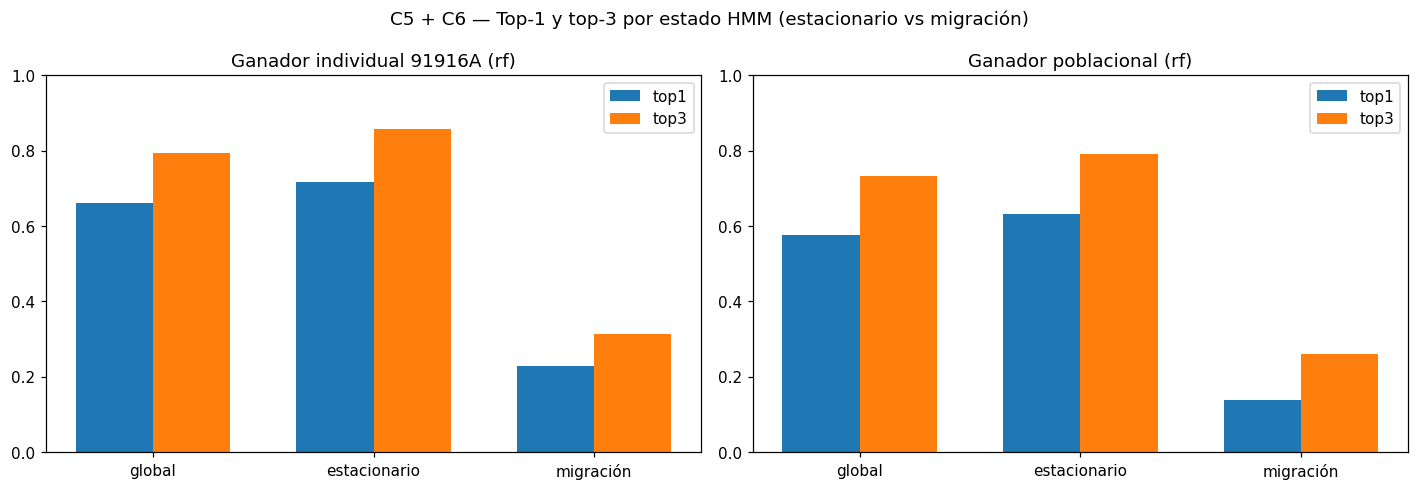

In [16]:
fig_state, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (table, label) in zip(
    axes, [(c5_table, f"individual {BIRD}"), (c6_table, "poblacional")],
):
    metrics_to_plot = ["top1", "top3"]
    states_order = ["global", "estacionario", "migración"]
    x = np.arange(len(states_order))
    width = 0.35
    for i, met in enumerate(metrics_to_plot):
        vals = [table[table["state"] == s][met].iloc[0] for s in states_order]
        ax.bar(x + (i - 0.5) * width, vals, width, label=met)
    ax.set_xticks(x)
    ax.set_xticklabels(states_order)
    ax.set_title(f"Ganador {label} ({table['modelo'].iloc[0]})")
    ax.set_ylim(0, 1)
    ax.legend()
fig_state.suptitle("C5 + C6 — Top-1 y top-3 por estado HMM (estacionario vs migración)")
fig_state.tight_layout()

save_artifact(
    slug="error-by-state-individual",
    objective="o4",
    num=6,
    decision="Top-1/top-3 por estado HMM causal para el modelo individual de 91916A",
    caption_es=(
        f"Accuracy del modelo individual de {BIRD} ({ganador_ind['modelo']}, "
        "entrenado solo con esa ave) desglosada por estado biológico (state_b_causal). "
        "Se mantiene el patrón del TFG: acierto alto en días estacionarios y caída "
        "en migración, ahora medido sobre un único individuo con ruta propia."
    ),
    fig=fig_state,
    table=c5_table,
    overwrite=True,
)
save_artifact(
    slug="error-by-state-poblacional",
    objective="o4",
    num=7,
    decision="Desglose de top-1 y top-3 por estado HMM causal para el ganador poblacional",
    caption_es=(
        f"Idem C5 para el ganador poblacional ({ganador_pob['modelo']}, sin "
        "bird_id). El patrón es el característico del pipeline: estacionario alto "
        "y migración baja, sobre las 82 aves. "
        "La coherencia entre ambos modos refuerza que el colapso en migración "
        "es estructural y no atribuible a la presencia o ausencia de la "
        "identidad del ave. Fenología de referencia: estado 1 (migración) "
        "representa el 11,7 % del test, concentrado en abr-may y sep-oct, "
        "coherente con la fenología conocida de Larus fuscus."
    ),
    fig=fig_state,
    table=c6_table,
    overwrite=True,
)

### C7 — Individual (91916A) vs poblacional@91916A

                 etiqueta      top1      top3  log_loss  dist_median_km
0           rf/individual  0.660099  0.793103  4.326926       14.390374
1          xgb/individual  0.640394  0.751232  4.564244       16.579868
2   rf/poblacional@91916A  0.652709  0.770936  2.724120       14.819201
3  xgb/poblacional@91916A  0.672414  0.790640  2.915298       16.579868
4     persistencia@91916A  0.689655  0.689655       NaN       16.561636
5           markov@91916A  0.662562  0.770936       NaN       14.819201


ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig08_individual-vs-poblacional.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab08_individual-vs-poblacional.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig08_individual-vs-poblacional.md'), ref='o4_fig08_individual-vs-poblacional')

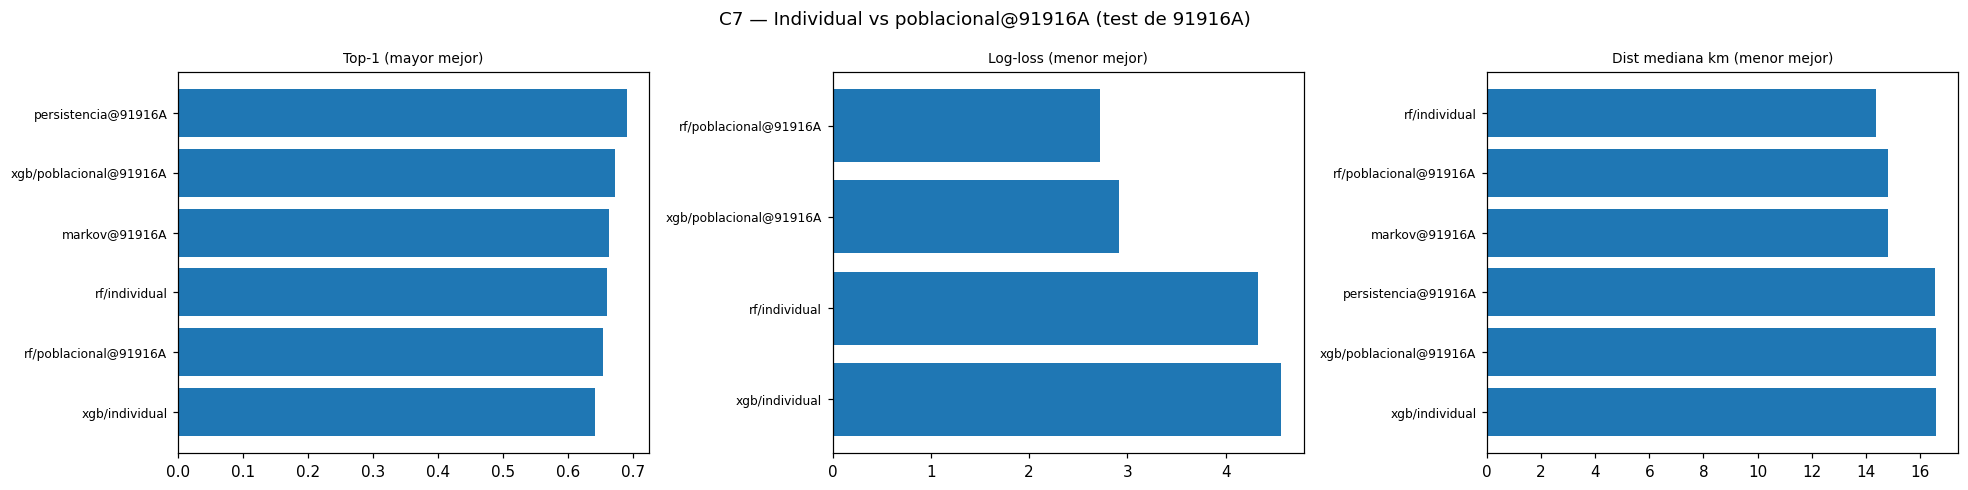

In [17]:
# C7 — Individual (91916A) vs poblacional@91916A + baselines, sobre el test de la ave.
contenders = [
    ("individual", "rf"), ("individual", "xgb"),
    (POB_AT, "rf"), (POB_AT, "xgb"),
]
test_m = metrics[metrics["split"] == "test"]
c7_rows = []
for modo, fam in contenders:
    r = test_m[(test_m["modo"] == modo) & (test_m["modelo"] == fam)]
    if len(r) == 0:
        continue
    r = r.iloc[0]
    c7_rows.append({"etiqueta": f"{fam}/{modo}", "top1": r["top1"], "top3": r["top3"],
                    "log_loss": r["log_loss"], "dist_median_km": r["dist_median_km"]})
for name in [f"persistencia@{BIRD}", f"markov@{BIRD}"]:
    r = test_m[test_m["modelo"] == name]
    if len(r) == 0:
        continue
    r = r.iloc[0]
    c7_rows.append({"etiqueta": name, "top1": r["top1"], "top3": r["top3"],
                    "log_loss": r["log_loss"], "dist_median_km": r["dist_median_km"]})
c7_table = pd.DataFrame(c7_rows)
print(c7_table.to_string())

fig_c7, axes_c7 = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (metric, title, asc) in zip(axes_c7, [
    ("top1", "Top-1 (mayor mejor)", False),
    ("log_loss", "Log-loss (menor mejor)", True),
    ("dist_median_km", "Dist mediana km (menor mejor)", True),
]):
    sub = c7_table.dropna(subset=[metric]).sort_values(metric, ascending=asc)
    ax.barh(range(len(sub)), sub[metric].to_numpy())
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub["etiqueta"], fontsize=8)
    ax.invert_yaxis(); ax.set_title(title, fontsize=9)
fig_c7.suptitle(f"C7 — Individual vs poblacional@{BIRD} (test de {BIRD})")
fig_c7.tight_layout()

save_artifact(
    slug="individual-vs-poblacional",
    objective="o4",
    num=8,
    decision=(
        f"Comparar el modelo per-individuo de {BIRD} contra el poblacional "
        f"evaluado sobre {BIRD} (poblacional@{BIRD}) y las baselines, mismas filas"
    ),
    caption_es=(
        f"Comparación manzanas-con-manzanas sobre el test del ave {BIRD}: el "
        f"modelo individual (RF/XGB entrenados solo con {BIRD}) frente al modelo "
        f"poblacional restringido a {BIRD} (poblacional@{BIRD}, RF/XGB) y las "
        f"baselines persistencia y Markov sobre esas mismas filas. Replica la "
        f"metodología de L3: si el individual no supera claramente a "
        f"poblacional@{BIRD}, se confirma que entrenar por-individuo no aporta "
        "frente al modelo global, reforzando la decisión 'global vs per-individuo' "
        "a favor del global."
    ),
    fig=fig_c7,
    table=c7_table,
    overwrite=True,
)

### C8 — Importancia de features de los dos ganadores

ArtifactPaths(figure=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/figures/o4_fig09_feature-importance-winners.png'), figure_pdf=None, table=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/tables/o4_tab09_feature-importance-winners.csv'), caption=PosixPath('/home/jllorens/Desktop/TFG/version3/reports/captions/o4_fig09_feature-importance-winners.md'), ref='o4_fig09_feature-importance-winners')

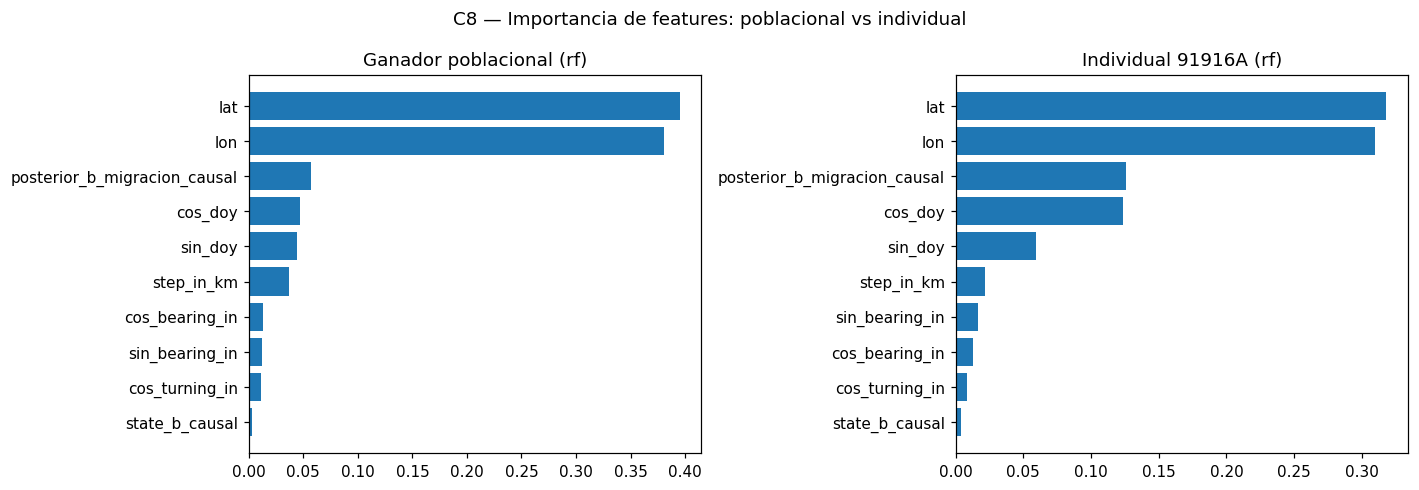

In [18]:
def _feature_importance(mode: str, family: str) -> pd.DataFrame:
    bundle = joblib.load(result.model_paths[f"{mode}_{family}"])
    model = bundle["model"]
    feature_cols = bundle["feature_cols"]
    if family == "rf":
        inner = model.named_steps["model"]
        imp = inner.feature_importances_
    elif family == "xgb":
        imp = model._xgb.feature_importances_
    else:  # lgbm
        imp = model._lgbm.booster_.feature_importance(importance_type="gain")
    df = pd.DataFrame({"feature": feature_cols, "importance": imp})
    df = df.sort_values("importance", ascending=False).reset_index(drop=True)
    df["modo"] = mode
    df["modelo"] = family
    return df


imp_pob = _feature_importance("poblacional", ganador_pob["modelo"])
imp_ind = _feature_importance("individual", ganador_ind["modelo"])

fig_c8, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in zip(
    axes, [imp_pob, imp_ind],
    [f"Ganador poblacional ({ganador_pob['modelo']})",
     f"Individual {BIRD} ({ganador_ind['modelo']})"],
):
    ax.barh(df["feature"], df["importance"]); ax.invert_yaxis(); ax.set_title(title)
fig_c8.suptitle("C8 — Importancia de features: poblacional vs individual")
fig_c8.tight_layout()
c8_table = pd.concat([imp_pob, imp_ind], ignore_index=True)
save_artifact(
    slug="feature-importance-winners",
    objective="o4",
    num=9,
    decision=(
        "Verificar que state_b_causal y posterior_b_migracion_causal se usan "
        "en ambos modelos"
    ),
    caption_es=(
        "Importancia relativa de las features para el ganador poblacional y el "
        "modelo individual de " + BIRD + " (pipeline causal: cinemática t-1→t y "
        "estado HMM forward-filtered). En ambos modelos lat y lon acaparan la "
        "mayor parte de la importancia, seguidos de las features de O3 "
        "(posterior_b_migracion_causal y, en menor medida, state_b_causal), lo "
        "que valida que el aporte de O3 al pipeline supervisado es real aunque "
        "secundario. La cinemática causal (step_in_km, cos_turning_in, "
        "sin/cos_bearing_in) ocupa posiciones intermedias en ambos modelos, "
        "con importancias modestas pero consistentes. El modelo individual no "
        "incluye la identidad del ave como feature; se entrena sobre un único "
        "individuo."
    ),
    fig=fig_c8,
    table=c8_table,
    overwrite=True,
)